In [309]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity as c_s
import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns = None

In [310]:
chefmozcuisine = pd.read_csv('/content/drive/MyDrive/Restaurant_recommendation/Restaurant_data/chefmozcuisine.csv' ,index_col = 'index')
chefmozhours4 = pd.read_csv('/content/drive/MyDrive/Restaurant_recommendation/Restaurant_data/chefmozhours4.csv',index_col = 'index')
rating_final = pd.read_csv('/content/drive/MyDrive/Restaurant_recommendation/Restaurant_data/rating_final.csv',index_col = 'index')
userprofile = pd.read_csv('/content/drive/MyDrive/Restaurant_recommendation/Restaurant_data/userprofile.csv',index_col = 'index')
chefmozaccepts = pd.read_csv('/content/drive/MyDrive/Restaurant_recommendation/Restaurant_data/chefmozaccepts.csv',index_col = 'index')
chefmozparking = pd.read_csv('/content/drive/MyDrive/Restaurant_recommendation/Restaurant_data/chefmozparking.csv',index_col = 'index')
geoplaces2 = pd.read_csv('/content/drive/MyDrive/Restaurant_recommendation/Restaurant_data/geoplaces2.csv',index_col = 'index')
usercuisine = pd.read_csv('/content/drive/MyDrive/Restaurant_recommendation/Restaurant_data/usercuisine.csv',index_col = 'index')
userpayment = pd.read_csv('/content/drive/MyDrive/Restaurant_recommendation/Restaurant_data/userpayment.csv',index_col = 'index')

In [311]:
chefmozcuisine.head()

,placeID,Rcuisine
index,,
0,135110,Spanish
1,135109,Italian
2,135107,Latin_American
3,135106,Mexican
4,135105,Fast_Food


In [312]:
chefmozhours4.head()

,placeID,hours,days
index,,,
0,135111,00:00-23:30;,Mon;Tue;Wed;Thu;Fri;
1,135111,00:00-23:30;,Sat;
2,135111,00:00-23:30;,Sun;
3,135110,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;
4,135110,00:00-00:00;,Sat;


In [313]:
rating_final.head()

,userID,placeID,rating,food_rating,service_rating
index,,,,,
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2


In [314]:
userprofile.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
index,,,,,,,,,,,,,,,,,,,
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53
4,U1005,22.183477,-100.959891,false,abstemious,no preference,family,public,single,independent,1992,none,thrifty-protector,Catholic,student,black,65,medium,1.69


In [315]:
chefmozaccepts.head()

,placeID,Rpayment
index,,
0,135110,cash
1,135110,VISA
2,135110,MasterCard-Eurocard
3,135110,American_Express
4,135110,bank_debit_cards


In [316]:
chefmozparking.head()

,placeID,parking_lot
index,,
0,135111,public
1,135110,none
2,135109,none
3,135108,none
4,135107,none


In [317]:
geoplaces2.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,zip,alcohol,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services
index,,,,,,,,,,,,,,,,,,,,,
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,?,No_Alcohol_Served,none,informal,no_accessibility,medium,kikucuernavaca.com.mx,familiar,f,closed,none
1,132825,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,?,78280,No_Alcohol_Served,none,informal,completely,low,?,familiar,f,open,none
2,135106,22.149709,-100.976093,0101000020957F0000649D6F21634858C119AE9BF528A3...,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,?,78000,Wine-Beer,only at bar,informal,partially,medium,?,familiar,f,open,none
3,132667,23.752697,-99.163359,0101000020957F00005D67BCDDED8157C1222A2DC8D84D...,little pizza Emilio Portes Gil,calle emilio portes gil,victoria,tamaulipas,?,?,?,No_Alcohol_Served,none,informal,completely,low,?,familiar,t,closed,none
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,?,No_Alcohol_Served,permitted,informal,completely,medium,?,familiar,t,closed,none


In [318]:
usercuisine.head()

,userID,Rcuisine
index,,
0,U1001,American
1,U1002,Mexican
2,U1003,Mexican
3,U1004,Bakery
4,U1004,Breakfast-Brunch


In [319]:
userpayment.head()

,userID,Upayment
index,,
0,U1001,cash
1,U1002,cash
2,U1003,cash
3,U1004,cash
4,U1004,bank_debit_cards


In [320]:
userDetail = pd.merge(left=usercuisine , right=userpayment ,on = 'userID')
del usercuisine
del userpayment
userDetail.head()

,userID,Rcuisine,Upayment
0,U1001,American,cash
1,U1002,Mexican,cash
2,U1003,Mexican,cash
3,U1004,Bakery,cash
4,U1004,Bakery,bank_debit_cards


In [321]:
userProfileDetail = pd.merge(left = userprofile ,right = userDetail ,on= 'userID')
del userprofile
del userDetail
userProfileDetail.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height,Rcuisine,Upayment
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77,American,cash
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87,Mexican,cash
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69,Mexican,cash
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53,Bakery,cash
4,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53,Bakery,bank_debit_cards


In [322]:
userProfileDetail.shape

(411, 21)

In [323]:
rating_final.shape

(1161, 5)

In [324]:
placeDetail = chefmozcuisine.merge(chefmozhours4 ,on='placeID')
placeDetail.head()

,placeID,Rcuisine,hours,days
0,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;
1,135110,Spanish,00:00-00:00;,Sat;
2,135110,Spanish,00:00-00:00;,Sun;
3,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;
4,135109,Italian,08:00-21:00;,Sat;


In [325]:
placeDetail = placeDetail.merge(chefmozaccepts ,on='placeID')
placeDetail = placeDetail.merge(chefmozparking ,on='placeID')
del chefmozaccepts
del chefmozparking
placeDetail.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot
0,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,cash,none
1,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,VISA,none
2,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,MasterCard-Eurocard,none
3,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,American_Express,none
4,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,bank_debit_cards,none


In [326]:
names = [
 'rating_final.csv',
 'geoplaces2.csv',
 'placeDetail',
 'userProfileDetail'
]

In [327]:
geoplaces2.replace({'?':'none'} ,inplace=True)

In [328]:
geoplaces2.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,zip,alcohol,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services
index,,,,,,,,,,,,,,,,,,,,,
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,none,none,No_Alcohol_Served,none,informal,no_accessibility,medium,kikucuernavaca.com.mx,familiar,f,closed,none
1,132825,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,none,78280,No_Alcohol_Served,none,informal,completely,low,none,familiar,f,open,none
2,135106,22.149709,-100.976093,0101000020957F0000649D6F21634858C119AE9BF528A3...,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,none,78000,Wine-Beer,only at bar,informal,partially,medium,none,familiar,f,open,none
3,132667,23.752697,-99.163359,0101000020957F00005D67BCDDED8157C1222A2DC8D84D...,little pizza Emilio Portes Gil,calle emilio portes gil,victoria,tamaulipas,none,none,none,No_Alcohol_Served,none,informal,completely,low,none,familiar,t,closed,none
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,none,none,No_Alcohol_Served,permitted,informal,completely,medium,none,familiar,t,closed,none


In [329]:
geoplaces2.drop(columns=['the_geom_meter','fax','zip','alcohol','dress_code','accessibility','url','franchise'] ,inplace=True)
geoplaces2.head()

,placeID,latitude,longitude,name,address,city,state,country,smoking_area,price,Rambience,area,other_services
index,,,,,,,,,,,,,
0,134999,18.915421,-99.184871,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,none,medium,familiar,closed,none
1,132825,22.147392,-100.983092,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,none,low,familiar,open,none
2,135106,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,none
3,132667,23.752697,-99.163359,little pizza Emilio Portes Gil,calle emilio portes gil,victoria,tamaulipas,none,none,low,familiar,closed,none
4,132613,23.752903,-99.165076,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,permitted,medium,familiar,closed,none


In [330]:
placeDetail.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot
0,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,cash,none
1,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,VISA,none
2,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,MasterCard-Eurocard,none
3,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,American_Express,none
4,135110,Spanish,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;,bank_debit_cards,none


In [331]:
placeDetail = placeDetail.merge(geoplaces2 ,on='placeID' )

In [332]:
placeDetail.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,smoking_area,price,Rambience,area,other_services
0,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;,cash,none,18.921785,-99.235350,Paniroles,none,none,none,none,not permitted,medium,quiet,closed,Internet
1,135109,Italian,08:00-21:00;,Sat;,cash,none,18.921785,-99.235350,Paniroles,none,none,none,none,not permitted,medium,quiet,closed,Internet
2,135109,Italian,08:00-21:00;,Sun;,cash,none,18.921785,-99.235350,Paniroles,none,none,none,none,not permitted,medium,quiet,closed,Internet
3,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,cash,none,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,none
4,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,VISA,none,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,none


In [333]:
userProfileDetail.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height,Rcuisine,Upayment
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77,American,cash
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87,Mexican,cash
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69,Mexican,cash
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53,Bakery,cash
4,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53,Bakery,bank_debit_cards


In [334]:
rating_final.head()

,userID,placeID,rating,food_rating,service_rating
index,,,,,
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2


In [335]:
placeDetail.to_csv('placeDetail.csv')
userProfileDetail.to_csv('userProfileDetail.csv')
rating_final.to_csv('rating_final.csv')

In [336]:
rating_final.describe()

,placeID,rating,food_rating,service_rating
count,1161.000000,1161.000000,1161.000000,1161.000000
mean,134192.041344,1.199828,1.215332,1.090439
std,1100.916275,0.773282,0.792294,0.790844
min,132560.000000,0.000000,0.000000,0.000000
25%,132856.000000,1.000000,1.000000,0.000000
50%,135030.000000,1.000000,1.000000,1.000000
75%,135059.000000,2.000000,2.000000,2.000000
max,135109.000000,2.000000,2.000000,2.000000


In [337]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

In [338]:
vectorizer = TfidfVectorizer()
onehotencoder = OneHotEncoder()

In [339]:
placeDetail.replace({'none': np.nan} ,inplace=True)
placeDetail.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,smoking_area,price,Rambience,area,other_services
0,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,18.921785,-99.235350,Paniroles,NaN,NaN,NaN,NaN,not permitted,medium,quiet,closed,Internet
1,135109,Italian,08:00-21:00;,Sat;,cash,NaN,18.921785,-99.235350,Paniroles,NaN,NaN,NaN,NaN,not permitted,medium,quiet,closed,Internet
2,135109,Italian,08:00-21:00;,Sun;,cash,NaN,18.921785,-99.235350,Paniroles,NaN,NaN,NaN,NaN,not permitted,medium,quiet,closed,Internet
3,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN
4,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,VISA,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN


In [340]:
placeDetail.shape

(645, 18)

In [341]:
placeDetail.isna().sum()

,0
placeID,0
Rcuisine,0
hours,0
days,0
Rpayment,0
parking_lot,213
latitude,0
longitude,0
name,0
address,90


In [342]:
placeDetail.country.unique()

array([nan, 'Mexico', 'mexico'], dtype=object)

In [343]:
placeDetail.country.replace({'mexico':'Mexico' ,np.nan :'Mexico'} ,inplace =True)
placeDetail.isna().sum()

,0
placeID,0
Rcuisine,0
hours,0
days,0
Rpayment,0
parking_lot,213
latitude,0
longitude,0
name,0
address,90


In [344]:
placeDetail.state.value_counts()

,count
state,
SLP,327
San Luis Potosi,87
Morelos,54
Tamaulipas,33
mexico,21
san luis potosi,21
san luis potos,15
S.L.P.,15
tamaulipas,12


<Axes: xlabel='state'>

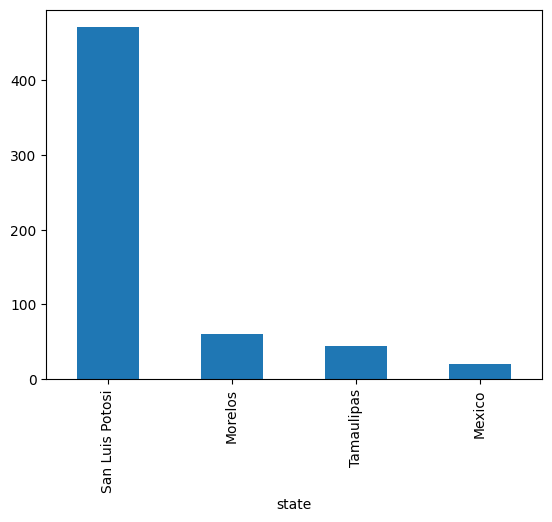

In [345]:
placeDetail.state.replace({
    'SLP':'San Luis Potosi' ,
    'san luis potosi':'San Luis Potosi',
    'san luis potos':'San Luis Potosi',
    'slp':'San Luis Potosi',
    's.l.p':'San Luis Potosi',
    'S.L.P':'San Luis Potosi',
    's.l.p.':'San Luis Potosi',
    'S.L.P.':'San Luis Potosi',
    'morelos':"Morelos",
    'tamaulipas':'Tamaulipas',
    'mexico':'Mexico'
} ,inplace = True)
placeDetail.state.value_counts().plot(kind='bar')

In [346]:
placeDetail.isna().sum()

,0
placeID,0
Rcuisine,0
hours,0
days,0
Rpayment,0
parking_lot,213
latitude,0
longitude,0
name,0
address,90


In [347]:
placeDetail.city.unique()

array([nan, 'San Luis Potosi', 'Cuernavaca', 'Soledad', 'san luis potosi',
       'san luis potos', 's.l.p', 'san luis potosi ', 's.l.p.',
       'cuernavaca', 'Jiutepec', 'Ciudad Victoria', 'Cd Victoria',
       'Cd. Victoria', 'victoria ', 'victoria'], dtype=object)

<Axes: xlabel='city'>

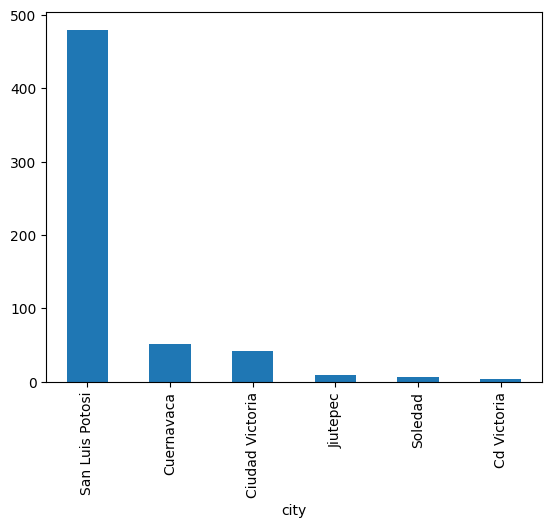

In [348]:
placeDetail.city.replace({
    'SLP':'San Luis Potosi' ,
    'san luis potosi ':'San Luis Potosi',
    'san luis potosi':'San Luis Potosi',
    'san luis potos':'San Luis Potosi',
    'slp':'San Luis Potosi',
    's.l.p':'San Luis Potosi',
    'S.L.P':'San Luis Potosi',
    's.l.p.':'San Luis Potosi',
    'S.L.P.':'San Luis Potosi',
    'victoria ':'Ciudad Victoria',
    'victoria':'Ciudad Victoria',
    'Cd. Victoria':'Ciudad Victoria',
    'cuernavaca':'Cuernavaca',
    'morelos':"Morelos",
    'tamaulipas':'Tamaulipas',
    'mexico':'Mexico'
} ,inplace = True)
placeDetail.city.value_counts().plot(kind='bar')

In [349]:
placeDetail.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,smoking_area,price,Rambience,area,other_services
0,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,18.921785,-99.235350,Paniroles,NaN,NaN,NaN,Mexico,not permitted,medium,quiet,closed,Internet
1,135109,Italian,08:00-21:00;,Sat;,cash,NaN,18.921785,-99.235350,Paniroles,NaN,NaN,NaN,Mexico,not permitted,medium,quiet,closed,Internet
2,135109,Italian,08:00-21:00;,Sun;,cash,NaN,18.921785,-99.235350,Paniroles,NaN,NaN,NaN,Mexico,not permitted,medium,quiet,closed,Internet
3,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN
4,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,VISA,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN


In [350]:
import pandas as pd

# Sample DataFrame (for testing purposes)
# placeDetail = pd.DataFrame({
#     'address': [...],
#     'state': [...],
#     'city': [...],
#     'country': [...],
#     'longitude': [...],
#     'latitude': [...]
# })

# Function to fill NaN values based on similar longitude and latitude
def fill_na_with_similar_lat_lon(df):
    # Create a copy of the DataFrame to avoid modifying the original during iteration
    df_filled = df.copy()

    # Define a precision for rounding longitude and latitude
    precision = 1

    # Round longitude and latitude for grouping
    df_filled['lon_lat'] = df_filled[['longitude', 'latitude']].round(precision).astype(str).agg('-'.join, axis=1)

    # Loop through rows with NaN in address, state, city, or country
    for index, row in df_filled.iterrows():
        if pd.isna(row[['address', 'state', 'city']]).any():
            # Find similar rows based on rounded longitude and latitude
            similar_rows = df_filled[df_filled['lon_lat'] == row['lon_lat']]

            # If there are similar rows, use them to fill NaN values
            if not similar_rows.empty:
                # Fill NaN values only if the mode exists
                for col in ['address', 'state', 'city']:
                    if pd.isna(row[col]):
                        mode_value = similar_rows[col].mode()
                        if not mode_value.empty:  # Check if mode value exists
                            df_filled.at[index, col] = mode_value[0]  # Take the first mode value
                        else:
                            df_filled.at[index, col] = None  # Or leave it as NaN if no mode is found

    # Drop the temporary lon_lat column
    df_filled.drop(columns=['lon_lat'], inplace=True)

    return df_filled

# Apply the function
placeDetail_filled = fill_na_with_similar_lat_lon(placeDetail)

# Check the filled DataFrame
placeDetail_filled


,placeID,Rcuisine,hours,days,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,smoking_area,price,Rambience,area,other_services
0,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
1,135109,Italian,08:00-21:00;,Sat;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
2,135109,Italian,08:00-21:00;,Sun;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
3,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN
4,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,VISA,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640,132572,Cafeteria,00:00-23:30;,Sat;,cash,yes,22.141647,-100.992712,Cafe Chaires,Lateral Salvador Nava Martinez 3145,San Luis Potosi,San Luis Potosi,Mexico,not permitted,low,familiar,closed,NaN
641,132572,Cafeteria,00:00-23:30;,Sun;,cash,yes,22.141647,-100.992712,Cafe Chaires,Lateral Salvador Nava Martinez 3145,San Luis Potosi,San Luis Potosi,Mexico,not permitted,low,familiar,closed,NaN
642,132560,Regional,08:00-12:00;,Mon;Tue;Wed;Thu;Fri;,cash,public,23.752304,-99.166913,puesto de gorditas,frente al tecnologico,Ciudad Victoria,Tamaulipas,Mexico,permitted,low,familiar,open,NaN
643,132560,Regional,00:00-00:00;,Sat;,cash,public,23.752304,-99.166913,puesto de gorditas,frente al tecnologico,Ciudad Victoria,Tamaulipas,Mexico,permitted,low,familiar,open,NaN


In [146]:
placeDetail_filled.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,smoking_area,price,Rambience,area,other_services
0,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
1,135109,Italian,08:00-21:00;,Sat;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
2,135109,Italian,08:00-21:00;,Sun;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
3,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN
4,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,VISA,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN


In [351]:
placeDetail_filled.isna().sum()

,0
placeID,0
Rcuisine,0
hours,0
days,0
Rpayment,0
parking_lot,213
latitude,0
longitude,0
name,0
address,6


In [352]:
placeDetail_filled.groupby('state')['city'].nunique()

,city
state,
Mexico,1
Morelos,2
San Luis Potosi,2
Tamaulipas,2


In [353]:
sc = placeDetail_filled[['state' ,'city']]
mode = sc.state.mode()[0]
sc.state.fillna(mode ,inplace=True)
sc.isna().sum()

,0
state,0
city,6


In [354]:
for s in sc.state.unique():
    print(s)
    mode = sc[sc.state == s].city.mode()[0]
    print('mode is :: ',mode)
    print('na value :: ',sc[sc.state == s].city.isna().sum())
sc.isna().sum()

Morelos
mode is ::  Cuernavaca
na value ::  0
San Luis Potosi
mode is ::  San Luis Potosi
na value ::  6
Tamaulipas
mode is ::  Ciudad Victoria
na value ::  0
Mexico
mode is ::  San Luis Potosi
na value ::  0


,0
state,0
city,6


In [355]:
mode = sc[sc.state == 'San Luis Potosi'].city.mode()[0]
sc.city.fillna(mode,inplace = True)
sc.isna().sum()

,0
state,0
city,0


In [356]:
placeDetail_filled.city.unique()

array(['Cuernavaca', 'San Luis Potosi', 'Ciudad Victoria', 'Soledad',
       'Jiutepec', 'Cd Victoria', None], dtype=object)

In [357]:
sc.replace({

})

,state,city
0,Morelos,Cuernavaca
1,Morelos,Cuernavaca
2,Morelos,Cuernavaca
3,San Luis Potosi,San Luis Potosi
4,San Luis Potosi,San Luis Potosi
...,...,...
640,San Luis Potosi,San Luis Potosi
641,San Luis Potosi,San Luis Potosi
642,Tamaulipas,Ciudad Victoria
643,Tamaulipas,Ciudad Victoria


In [358]:
placeDetail_filled[['state' ,'city']] = sc
placeDetail_filled.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,smoking_area,price,Rambience,area,other_services
0,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
1,135109,Italian,08:00-21:00;,Sat;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
2,135109,Italian,08:00-21:00;,Sun;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
3,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN
4,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,VISA,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN


In [359]:
placeDetail = placeDetail_filled.copy()

In [360]:
placeDetail.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,smoking_area,price,Rambience,area,other_services
0,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
1,135109,Italian,08:00-21:00;,Sat;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
2,135109,Italian,08:00-21:00;,Sun;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,not permitted,medium,quiet,closed,Internet
3,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN
4,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,VISA,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,only at bar,medium,familiar,open,NaN


In [361]:
placeDetail.isna().sum()

,0
placeID,0
Rcuisine,0
hours,0
days,0
Rpayment,0
parking_lot,213
latitude,0
longitude,0
name,0
address,6


In [362]:
placeDetail.drop(columns=['smoking_area','other_services'] ,inplace=True)

In [363]:
placeDetail.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,price,Rambience,area
0,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
1,135109,Italian,08:00-21:00;,Sat;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
2,135109,Italian,08:00-21:00;,Sun;,cash,NaN,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
3,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,cash,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
4,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,VISA,NaN,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open


In [364]:
placeDetail.address.isna().sum()

6

In [365]:
uni_city = placeDetail.city.unique()

In [366]:
for c in uni_city:
    mode = placeDetail[placeDetail.city == c].address.mode()
    if not mode.empty :
        mode = mode[0]
        placeDetail.loc[(placeDetail.city == c) & (placeDetail.address.isna()),'address'] = mode
        print('mode is :: ',mode)
placeDetail.address.isna().sum()

mode is ::  Domingo 10 711 El Empleado
mode is ::  Satelite 606 Satelite
mode is ::  Calle Mezquite Fracc Framboyanes
mode is ::  524 Soledad de Graciano Sanchez
mode is ::  Paseo de las Fuentes
mode is ::  Calle Mezquite Fracc Framboyanes


0

In [367]:
print(rating_final.duplicated(['placeID','userID']).sum())
user_rating = rating_final[(rating_final['userID'] == 'U1001') & (rating_final['rating'] >= 1)]
user_rating

0


,userID,placeID,rating,food_rating,service_rating
index,,,,,
215,U1001,132830,1,1,1
216,U1001,132825,2,2,1
689,U1001,135040,1,1,1
690,U1001,135039,1,1,1
691,U1001,135045,1,1,1
692,U1001,135033,1,1,1
693,U1001,135025,2,2,2
694,U1001,135051,1,1,2


In [368]:
rating_final.shape

(1161, 5)

In [369]:
placeDetail['parking_lot'].fillna('no', inplace=True)

In [370]:
placeDetail.head()

,placeID,Rcuisine,hours,days,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,price,Rambience,area
0,135109,Italian,08:00-21:00;,Mon;Tue;Wed;Thu;Fri;,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
1,135109,Italian,08:00-21:00;,Sat;,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
2,135109,Italian,08:00-21:00;,Sun;,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
3,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,cash,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
4,135106,Mexican,18:00-23:30;,Mon;Tue;Wed;Thu;Fri;,VISA,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open


In [371]:
placeDetail.drop(columns=['days','hours'] ,inplace=True)

In [372]:
placeDetail.head()

,placeID,Rcuisine,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,price,Rambience,area
0,135109,Italian,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
1,135109,Italian,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
2,135109,Italian,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
3,135106,Mexican,cash,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
4,135106,Mexican,VISA,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open


In [373]:
rated_places = rating_final["placeID"].values.tolist()
print('initial shape :: ',rating_final.shape)
for r in rated_places :
    row = placeDetail[placeDetail['placeID']==r]
    if row.shape[0]==0 :
        r = rating_final[rating_final['placeID'] == r].index.values[0]
        rating_final.drop(index = r ,inplace=True)
print('final shape :: ',rating_final.shape)

initial shape ::  (1161, 5)
final shape ::  (815, 5)


In [374]:
rating_final.head()

,userID,placeID,rating,food_rating,service_rating
index,,,,,
0,U1077,135085,2,2,2
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2
5,U1068,132740,0,0,0


In [375]:
placeDetail.price.isna().sum()

0

In [376]:
placeDetail.Rambience.isna().sum()

0

In [377]:
print(placeDetail.Rambience.unique())
placeDetail.Rambience.value_counts()

['quiet' 'familiar']


,count
Rambience,
familiar,603
quiet,42


In [378]:
placeDetail.head()

,placeID,Rcuisine,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,price,Rambience,area
0,135109,Italian,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
1,135109,Italian,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
2,135109,Italian,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
3,135106,Mexican,cash,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
4,135106,Mexican,VISA,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open


In [379]:
# df = placeDetail.drop_duplicates('placeID').reset_index()
df = placeDetail.drop_duplicates(subset=['placeID', 'Rcuisine', 'Rpayment']).reset_index()
df.drop(columns='index' ,inplace=True)
df.head()

,placeID,Rcuisine,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,price,Rambience,area
0,135109,Italian,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
1,135106,Mexican,cash,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
2,135106,Mexican,VISA,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
3,135106,Mexican,MasterCard-Eurocard,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
4,135104,Mexican,cash,yes,23.752982,-99.168434,vips,Calle Mezquite Fracc Framboyanes,Ciudad Victoria,Tamaulipas,Mexico,medium,familiar,closed


In [380]:
df.shape

(215, 14)

In [381]:


# Step 1: Check which restaurants have multiple payment methods or multiple cuisines
multiple_payment_methods = df.groupby('placeID').filter(lambda x: x['Rpayment'].nunique() > 1)
multiple_cuisines = df.groupby('placeID').filter(lambda x: x['Rcuisine'].nunique() > 1)

# Step 2: One-hot encode the 'Rpayment' and 'Rcuisine' columns
payment_dummies = pd.get_dummies(df['Rpayment'], prefix='payment')
cuisine_dummies = pd.get_dummies(df['Rcuisine'], prefix='cuisine')

# Step 3: Concatenate the one-hot encoded columns to the original DataFrame
df_encoded = pd.concat([df, payment_dummies, cuisine_dummies], axis=1)

# Step 4: Drop the original 'Rpayment' and 'Rcuisine' columns as they are now encoded
df_encoded.drop(['Rpayment', 'Rcuisine'], axis=1, inplace=True)

# Step 5: Group the DataFrame by placeID and other relevant columns, then aggregate the payment and cuisine columns
df_grouped = df_encoded.groupby(
    ['placeID', 'parking_lot', 'latitude', 'longitude', 'name',
     'address', 'city', 'state', 'country', 'price', 'Rambience', 'area'],
    as_index=False
).max()

# Step 6: Display the final DataFrame with both payment and cuisine one-hot encoded and grouped
df_grouped

# Step 7: (Optional) Check which restaurants had multiple payment methods or cuisines originally
multiple_payment_methods[['placeID', 'Rpayment']].drop_duplicates()
multiple_cuisines[['placeID', 'Rcuisine']].drop_duplicates()



,placeID,Rcuisine
8,135086,Burgers
11,135086,Fast_Food
21,135073,Bar
24,135073,Bar_Pub_Brewery
31,135071,Bar
35,135071,Bar_Pub_Brewery
56,135053,Cafeteria
60,135053,Fast_Food
64,135053,Pizzeria
68,135052,Bar


In [382]:
df_grouped.head()

,placeID,parking_lot,latitude,longitude,name,address,city,state,country,price,Rambience,area,payment_American_Express,payment_Carte_Blanche,payment_MasterCard-Eurocard,payment_VISA,payment_bank_debit_cards,payment_cash,cuisine_American,cuisine_Armenian,cuisine_Bakery,cuisine_Bar,cuisine_Bar_Pub_Brewery,cuisine_Breakfast-Brunch,cuisine_Burgers,cuisine_Cafe-Coffee_Shop,cuisine_Cafeteria,cuisine_Chinese,cuisine_Contemporary,cuisine_Family,cuisine_Fast_Food,cuisine_Game,cuisine_International,cuisine_Italian,cuisine_Japanese,cuisine_Mexican,cuisine_Pizzeria,cuisine_Regional,cuisine_Seafood,cuisine_Vietnamese
0,132560,public,23.752304,-99.166913,puesto de gorditas,frente al tecnologico,Ciudad Victoria,Tamaulipas,Mexico,low,familiar,open,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,132572,yes,22.141647,-100.992712,Cafe Chaires,Lateral Salvador Nava Martinez 3145,San Luis Potosi,San Luis Potosi,Mexico,low,familiar,closed,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,132584,yes,23.752365,-99.165288,Gorditas Dona Tota,Calle Mezquite Fracc Framboyanes,Ciudad Victoria,Tamaulipas,Mexico,medium,familiar,closed,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,132594,public,23.752168,-99.165709,tacos de barbacoa enfrente del Tec,Calle Mezquite Fracc Framboyanes,Ciudad Victoria,Tamaulipas,Mexico,low,familiar,open,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,132608,public,23.758805,-99.165130,Hamburguesas La perica,cd. mier,Ciudad Victoria,Tamaulipas,Mexico,low,quiet,open,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [383]:
df_grouped.shape

(85, 40)

In [384]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [385]:
# Define the transformer for restaurant features
restaurant_features = ColumnTransformer(
    transformers=[
        ('cuisine', OneHotEncoder(), ['cuisine_American','cuisine_Armenian','cuisine_Bakery','cuisine_Bar','cuisine_Bar_Pub_Brewery','cuisine_Breakfast-Brunch','cuisine_Burgers','cuisine_Cafe-Coffee_Shop',
                                      'cuisine_Cafeteria','cuisine_Chinese','cuisine_Contemporary','cuisine_Family','cuisine_Fast_Food','cuisine_Game','cuisine_International',
                                      'cuisine_Italian','cuisine_Japanese','cuisine_Mexican','cuisine_Pizzeria','cuisine_Regional','cuisine_Seafood','cuisine_Vietnamese']),
        ('payment', OneHotEncoder(), ['payment_American_Express', 'payment_Carte_Blanche', 'payment_MasterCard-Eurocard', 'payment_VISA',
                                      'payment_bank_debit_cards', 'payment_cash']),
        ('parking', OneHotEncoder(), ['parking_lot']),
        ('latitude', StandardScaler(), ['latitude']),
        ('longitude', StandardScaler(), ['longitude']),
        ('price', OneHotEncoder(), ['price']),
        ('area', OneHotEncoder(), ['area']),
        ('ambience', OneHotEncoder(), ['Rambience']),
        ('name', TfidfVectorizer(), 'name'),
        ('address', TfidfVectorizer(), 'address'),
        ('city', TfidfVectorizer(), 'city'),
        ('state', TfidfVectorizer(), 'state')
    ],
    remainder='drop'
)

In [386]:
restaurant_feature_matrix = restaurant_features.fit_transform(df_grouped)
restaurant_feature_matrix

<85x395 sparse matrix of type '<class 'numpy.float64'>'
	with 3884 stored elements in Compressed Sparse Row format>

In [387]:
def create_user_profile(user_id, ratings_df, restaurants_df, feature_matrix, min_rating=1):
    # Filter ratings for the specific user and only consider ratings >= min_rating
    user_ratings = ratings_df[(ratings_df['userID'] == user_id) & (ratings_df['rating'] >= min_rating)]

    # Get the restaurant indices that the user has rated
    rated_restaurant_ids = user_ratings['placeID'].tolist()
    rated_restaurant_indices = restaurants_df[restaurants_df['placeID'].isin(rated_restaurant_ids)].index.values.tolist()

    # Select the feature vectors for these restaurants
    rated_features = feature_matrix[rated_restaurant_indices].toarray()  # Convert to dense array if needed


    # Get the corresponding ratings and reshape them
    ratings = user_ratings['rating'].values.reshape(-1, 1)

    # Weight the features by the ratings
    weighted_features = rated_features * ratings

    # Calculate the user profile by averaging the weighted features
    user_profile = np.sum(weighted_features, axis=0) / np.sum(ratings)

    return user_profile

# Example: Create a user profile for user U1001
user_profile = create_user_profile('U1001', rating_final, df_grouped, restaurant_feature_matrix)
user_profile

array([ 1.        ,  0.        ,  1.        ,  0.        ,  1.        ,
        0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  1.        ,  0.        ,  1.        ,
        0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  1.        ,  0.        ,  1.        ,
        0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  1.        ,  0.        ,  0.4       ,
        0.6       ,  1.        ,  0.        ,  1.        ,  0.        ,
        0.6       ,  0.4       ,  1.        ,  0.        ,  0.8       ,
        0.2       ,  1.        ,  0.        ,  0.8       ,  0.2       ,
        0.8       ,  0.2       ,  1.        ,  0.        ,  1.        ,
        0.6       ,  0.        ,  0.        ,  0.4       ,  0.04784141,
       -0.62583633,  0.        ,  0.8       ,  0.2       ,  0.6       ,
        0.4       ,  1.        ,  0.        ,  0.        ,  0.  

In [388]:
user_profiles = {}

for user_id in rating_final['userID'].unique():
    user_profile = create_user_profile(user_id, rating_final, df_grouped, restaurant_feature_matrix)

    # Store the user profile in the dictionary
    user_profiles[user_id] = user_profile

user_profiles_df = pd.DataFrame(user_profiles).T

user_profiles_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394
U1077,1.0,0.0,1.000000,0.000000,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.8,0.2,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.600000,0.400000,1.000000,0.000000,1.0,0.0,0.6,0.4,1.0,0.0,1.0,0.0,1.0,0.0,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.0,0.800000,0.200000,0.0,0.000000,0.051558,-0.628786,0.0,0.400000,0.600000,0.600000,0.400000,1.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.174426,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.121045,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.121045,0.0,0.0,0.261897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.269867,0.0,0.0,0.151064,0.0,0.0,0.0,0.0,0.0,0.0,0.261897,0.0,0.0,0.0,0.0,0.0,0.0,0.238218,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.103423,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.128581,0.0,0.221027,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.221027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.085116,0.0,0.0,0.0,0.231429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.169265,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.185021,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.185021,0.0,0.0,0.0,0.0,0.202204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.185021,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.169265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.094749,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.57735,0.57735,0.57735,0.0,0.000000,0.57735,0.0,0.0,0.57735,0.57735,0.0
U1068,1.0,0.0,1.000000,0.000000,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.333333,0.666667,0.666667,0.333333,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.333333,0.666667,0.333333,0.666667,0.666667,0.333333,1.0,0.000000,0.333333,0.0,0.666667,1.331807,1.613831,0.0,0.333333,0.666667,0.666667,0.333333,1.0,0.0,0.0,0.000000,0.0,0.0,0.153238,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.245942,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090609,0.130929,0.0,0.0,0.0,0.000000,0.0,0.0000

In [413]:
def recommend(userid ,userProfile ,restaurant_feature_matrix ,top_n = 20):
    user = userProfile.loc[userid].values.reshape(1,-1)
    similarity = calculate_similarity(user ,restaurant_feature_matrix)
    top = similarity.argsort()[0][-top_n:][::-1]
    return df.iloc[top]
    # recommended_restaurants = df.iloc[top]

    # Drop duplicate restaurants based on 'placeID'
    # unique_recommendations = recommended_restaurants.drop_duplicates(subset='placeID')

    # return unique_recommendations

In [402]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_similarity(user_vector, restaurant_features):
    return cosine_similarity(user_vector, restaurant_features)


In [417]:
class RecommendationModel:
    def __init__(self, user_profiles, restaurant_features):
        self.user_profiles = user_profiles
        self.restaurant_features = restaurant_features

    def calculate_similarity(self, user_vector):
        return cosine_similarity(user_vector, self.restaurant_features)

    def recommend(self, user_id, top_n=30):
        user_vector = self.user_profiles.loc[user_id].values.reshape(1, -1)
        similarity = self.calculate_similarity(user_vector)

        top_indices = similarity.argsort()[0][-top_n:][::-1]
        # return df.iloc[top_indices]
        recommended_restaurants = df.iloc[top_indices]

        unique_recommendations = recommended_restaurants.drop_duplicates(subset='placeID')

        return unique_recommendations['placeID'].tolist()

In [418]:
recommendation_model = RecommendationModel(user_profiles_df, restaurant_feature_matrix)

recommended_restaurants = recommendation_model.recommend('U1067')
recommended_restaurants

[135109,
 135106,
 135079,
 135086,
 135104,
 135044,
 135085,
 135088,
 135073,
 135060,
 135071,
 135053,
 135052,
 135058,
 135072]

In [407]:
# recommendation_model = RecommendationModel(user_profiles_df, restaurant_feature_matrix)

# recommended_restaurants = recommendation_model.recommend('U1067', top_n=5).drop_duplicates(subset='placeID')
# recommended_restaurants


In [399]:
recommend('U1067' ,user_profiles_df ,restaurant_feature_matrix,5)

,placeID,Rcuisine,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,price,Rambience,area
0,135109,Italian,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
3,135106,Mexican,MasterCard-Eurocard,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
2,135106,Mexican,VISA,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
15,135079,Chinese,cash,no,22.156376,-100.998355,Koye Sushi,Nereo Rodriguez Barragan 450 E Centro,San Luis Potosi,San Luis Potosi,Mexico,high,familiar,closed
13,135086,Fast_Food,MasterCard-Eurocard,yes,22.141421,-101.013955,Mcdonalds Parque Tangamanga,Lateral Salvador Nava Martinez 3145,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,closed


In [400]:
recommendations = recommend('U1067', user_profiles_df, restaurant_feature_matrix)

# Ensure the results are unique based on 'placeID'
unique_recommendations = recommendations.drop_duplicates(subset='placeID')

# Display the unique recommendations
unique_recommendations

,placeID,Rcuisine,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,price,Rambience,area
0,135109,Italian,cash,no,18.921785,-99.235350,Paniroles,Domingo 10 711 El Empleado,Cuernavaca,Morelos,Mexico,medium,quiet,closed
3,135106,Mexican,MasterCard-Eurocard,no,22.149709,-100.976093,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,open
15,135079,Chinese,cash,no,22.156376,-100.998355,Koye Sushi,Nereo Rodriguez Barragan 450 E Centro,San Luis Potosi,San Luis Potosi,Mexico,high,familiar,closed
13,135086,Fast_Food,MasterCard-Eurocard,yes,22.141421,-101.013955,Mcdonalds Parque Tangamanga,Lateral Salvador Nava Martinez 3145,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,closed
6,135104,Mexican,MasterCard-Eurocard,yes,23.752982,-99.168434,vips,Calle Mezquite Fracc Framboyanes,Ciudad Victoria,Tamaulipas,Mexico,medium,familiar,closed
82,135044,Chinese,cash,no,22.141848,-100.997475,Restaurant Wu Zhuo Yi,Himno Nacional 100 Avenida,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,closed
14,135085,Fast_Food,cash,public,22.150802,-100.982680,Tortas Locas Hipocampo,Venustiano Carranza 719 Centro,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,closed
7,135088,Cafeteria,cash,public,18.876011,-99.219890,Cafeteria cenidet,Interior Internado Palmira SN,Cuernavaca,Morelos,Mexico,low,quiet,closed
22,135073,Bar,VISA,yes,22.147175,-100.974269,Restaurante Bar El Gallinero,Pascual M. Hernandez 210 Centro,San Luis Potosi,San Luis Potosi,Mexico,high,familiar,closed
40,135060,Seafood,cash,no,22.156883,-100.978485,Restaurante Marisco Sam,Ignacio Allende 785 Centro,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,closed


In [401]:
recommend('U1106' ,user_profiles_df ,restaurant_feature_matrix ,8)

,placeID,Rcuisine,Rpayment,parking_lot,latitude,longitude,name,address,city,state,country,price,Rambience,area
58,135053,Cafeteria,MasterCard-Eurocard,yes,22.178931,-101.012861,La Fontana Pizza Restaurante and Cafe,Satelite 606 Satelite,San Luis Potosi,San Luis Potosi,Mexico,high,familiar,closed
16,135079,Chinese,American_Express,no,22.156376,-100.998355,Koye Sushi,Nereo Rodriguez Barragan 450 E Centro,San Luis Potosi,San Luis Potosi,Mexico,high,familiar,closed
24,135073,Bar_Pub_Brewery,cash,yes,22.147175,-100.974269,Restaurante Bar El Gallinero,Pascual M. Hernandez 210 Centro,San Luis Potosi,San Luis Potosi,Mexico,high,familiar,closed
40,135060,Seafood,cash,no,22.156883,-100.978485,Restaurante Marisco Sam,Ignacio Allende 785 Centro,San Luis Potosi,San Luis Potosi,Mexico,medium,familiar,closed
39,135069,Bar,cash,yes,22.140129,-100.944872,Abondance Restaurante Bar,Industrias 908 Valle Dorado,San Luis Potosi,San Luis Potosi,Mexico,low,familiar,closed
60,135053,Fast_Food,cash,yes,22.178931,-101.012861,La Fontana Pizza Restaurante and Cafe,Satelite 606 Satelite,San Luis Potosi,San Luis Potosi,Mexico,high,familiar,closed
63,135053,Fast_Food,American_Express,yes,22.178931,-101.012861,La Fontana Pizza Restaurante and Cafe,Satelite 606 Satelite,San Luis Potosi,San Luis Potosi,Mexico,high,familiar,closed
71,135052,Bar_Pub_Brewery,cash,no,22.150981,-100.977412,La Cantina Restaurante,Ignacio Aldama 300 Centro,San Luis Potosi,San Luis Potosi,Mexico,high,familiar,closed


In [416]:
import pickle

# Save the model
with open('recommendation_model.pkl', 'wb') as f:
    pickle.dump(recommendation_model, f)

print("Model saved to trained_model.pkl")


Model saved to trained_model.pkl
